Published on December 24, 2022 by Marília Prata, mpwolke.

In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

import plotly.graph_objects as go
import plotly.express as px

from subprocess import check_output
from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)

import warnings
warnings.simplefilter(action='ignore', category=Warning)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/meta-kaggle/KernelTags.csv
/kaggle/input/meta-kaggle/KernelVersionCompetitionSources.csv
/kaggle/input/meta-kaggle/Datasets.csv
/kaggle/input/meta-kaggle/KernelVersionKernelSources.csv
/kaggle/input/meta-kaggle/KernelVotes.csv
/kaggle/input/meta-kaggle/Submissions.csv
/kaggle/input/meta-kaggle/KernelLanguages.csv
/kaggle/input/meta-kaggle/Users.csv
/kaggle/input/meta-kaggle/ForumMessageVotes.csv
/kaggle/input/meta-kaggle/Competitions.csv
/kaggle/input/meta-kaggle/DatasetTaskSubmissions.csv
/kaggle/input/meta-kaggle/UserAchievements.csv
/kaggle/input/meta-kaggle/UserOrganizations.csv
/kaggle/input/meta-kaggle/Teams.csv
/kaggle/input/meta-kaggle/UserFollowers.csv
/kaggle/input/meta-kaggle/CompetitionTags.csv
/kaggle/input/meta-kaggle/Kernels.csv
/kaggle/input/meta-kaggle/Organizations.csv
/kaggle/input/meta-kaggle/Datasources.csv
/kaggle/input/meta-kaggle/ForumTopics.csv
/kaggle/input/meta-kaggle/DatasetVersions.csv
/kaggle/input/meta-kaggle/DatasetVotes.csv
/kaggle/input/m

In [9]:
df = pd.read_csv("/kaggle/input/meta-kaggle/Competitions.csv", delimiter=',', encoding='utf-8')
pd.set_option('display.max_columns', None)
df.head(7)

,Id,Slug,Title,Subtitle,HostSegmentTitle,ForumId,OrganizationId,CompetitionTypeId,HostName,EnabledDate,DeadlineDate,ProhibitNewEntrantsDeadlineDate,TeamMergerDeadlineDate,TeamModelDeadlineDate,ModelSubmissionDeadlineDate,FinalLeaderboardHasBeenVerified,HasKernels,OnlyAllowKernelSubmissions,HasLeaderboard,LeaderboardPercentage,LeaderboardDisplayFormat,EvaluationAlgorithmAbbreviation,EvaluationAlgorithmName,EvaluationAlgorithmDescription,EvaluationAlgorithmIsMax,ValidationSetName,ValidationSetValue,MaxDailySubmissions,NumScoredSubmissions,MaxTeamSize,BanTeamMergers,EnableTeamModels,EnableSubmissionModelHashes,EnableSubmissionModelAttachments,RewardType,RewardQuantity,NumPrizes,UserRankMultiplier,CanQualifyTiers,TotalTeams,TotalCompetitors,TotalSubmissions
0,2408,Eurovision2010,Forecast Eurovision Voting,This competition requires contestants to forec...,Featured,2.0,NaN,1,NaN,04/07/2010 07:57:43,05/25/2010 18:00:00,NaN,NaN,NaN,NaN,True,True,False,False,10,0.0,AE,Absolute Error,Total sum of absolute value of each individual...,False,NaN,NaN,5,5,20,False,False,False,False,USD,1000.0,1,1.0,False,22,25,22
1,2435,hivprogression,Predict HIV Progression,This contest requires competitors to predict t...,Featured,1.0,NaN,1,NaN,04/27/2010 21:29:09,08/02/2010 12:32:00,NaN,NaN,NaN,NaN,True,True,False,True,30,0.0,MCE,Mean Consequential Error,Averages consequential error (i.e. if predicti...,True,Boolean,"{0, 1}",4,4,20,False,False,False,False,USD,500.0,1,1.0,True,107,116,855
2,2438,worldcup2010,World Cup 2010 - Take on the Quants,Quants at Goldman Sachs and JP Morgan have mod...,Featured,NaN,NaN,1,NaN,06/03/2010 08:08:08,06/11/2010 13:29:00,NaN,NaN,NaN,NaN,True,True,False,False,10,0.0,Custom,Custom Evaluation Metric,A placeholder that indicates a custom algorith...,False,NaN,NaN,5,5,20,False,False,False,False,USD,100.0,1,0.5,False,0,0,0
3,2439,informs2010,INFORMS Data Mining Contest 2010,The goal of this contest is to predict short t...,Featured,4.0,NaN,1,NaN,06/21/2010 21:53:25,10/10/2010 02:28:00,NaN,NaN,NaN,NaN,True,True,False,True,10,0.0,AUC,Area Under Receiver Operating Characteristic C...,Measures discrimination. Calculates how well a...,True,A real number,"(-Infinity, Infinity)",5,5,20,False,False,False,False,USD,0.0,1,1.0,True,145,153,1483
4,2442,worldcupconf,World Cup 2010 - Confidence Challenge,The Confidence Challenge requires competitors ...,Featured,3.0,NaN,1,NaN,06/03/2010 08:08:08,06/11/2010 13:28:00,NaN,NaN,NaN,NaN,True,True,False,False,10,0.0,Custom,Custom Evaluation Metric,A placeholder that indicates a custom algorith...,False,NaN,NaN,5,5,20,False,False,False,False,USD,100.0,1,0.5,False,63,64,63
5,2445,unimelb,Predict Grant Applications,This task requires participants to predict the...,Featured,30.0,NaN,1,NaN,12/13/2010 09:22:46,02/20/2011 22:00:00,NaN,NaN,NaN,NaN,True,True,False,True,25,0.0,AUC,Area Under Receiver Operating Characteristic C...,Measures discrimination. Calculates how well a...,True,A real number,"(-Infinity, Infinity)",2,5,20,False,False,False,False,USD,5000.0,1,1.0,True,203,216,2792
6,2447,chess,Chess ratings - Elo versus the Rest of the World,This competition aims to discover whether othe...,Featured,18.0,NaN,1,NaN,08/03/2010 00:00:00,11/17/2010 20:00:00,NaN,NaN,NaN,NaN,True,True,False,True,20,0.0,RMSE,Root Mean Squared Error,Square root of the average of the squared errors.,False,NaN,NaN,2,2,20,False,False,False,False,USD,617.0,10,1.0,True,252,262,3228


#Host Segment Title

In [10]:
df["HostSegmentTitle"].value_counts()

Community          5036
Featured            225
Research            146
Playground           98
Recruitment          17
Prospect              7
Getting Started       6
GE Quests             5
Name: HostSegmentTitle, dtype: int64

#We had already 5036 Community Competitions!

In [2]:
!pip install stylecloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.1/262.1 kB 5.2 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.4/161.4 kB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for stylecloud: filename=stylecloud-0.5.2-py3-none-any.whl size=259508 sha256=c20b8ede7bcd618140cb9d05452816cac742b11b8f815954461654091e21d8ea
  Stored in directory: /root/.cache/pip/wheels/77/42/7a/f52b5f84c04196fd4c2a3dceeb1bbeaee1c93a4fe271b5eb41
  Created wheel for fire: filename=fire-0.5.0-py2.py3-none-any.whl size=116951 sha256=3c1a3934c7eb72a014c6f3ddc58abfe031f967e23a0696797ab23d6d280235b6
  Stored in directory: /root/.cache/pip/wheels/20/97/e1/dd2c472bebcdcaa85fdc07d0f19020299f1c86773028860c53
  Created wheel for ti

In [3]:
import stylecloud
from IPython.display import Image

In [4]:
text = "Competitions.Sharing. GM. Data Science. Medals. Learning. Machine Learning. Solutions. Medals. Write-ups. DatasetTags. Medals. Solutions. Learning. Downvotes. Learning. GrandMasters. Solutions. Upvotes. Learning. Votes. Solutions. Upvotes. DatasetTasks. Solutions. Learning. Upvotes. GrandMasters. Votes. Gms. Upvotes. EpisodeAgents. Upvotes. GMs. Masters. Upvotes. Medals. GMs. ForumMessages. Medals.Learning. Notebooks. Downvotes. Sharing.Notebooks. ForumTopics.Notebooks. Downvotes. Kaggle. Notebooks.  Learning. Kaggle. KernelLanguages. Kaggle. Sharing. Kaggle. Medals. Kaggle. Learning. Kernel. Kaggle. Votes. Kaggle. Medals.Learning.Kaggle. Organizations.Kaggle. GoldMedal.Kaggle. Submissions. Kaggle. Rankings.Kaggle. GoldMedal. Kaggle. Teams. Kaggle. GoldMedal. Kaggle. UserAchievements.Rankings. Kaggle. Downvotes.Kaggle. UserFollowers. Rankings. Kaggle"

In [14]:
concat_quotes = "Competitions.Sharing. GM. Data Science. Competitions. Learning. Machine Learning. Solutions. Medals. Happy Hanukkah. Write-ups. Machine Learning. DatasetTags. Happy Kwanzaa. Data Science. Competitions. Sharing. Machine Learning. MerryXmas. Learning. Gms. Merry Xmas. Kaggle. Data Science. GrandMasters. Solutions. Happy Kwanzaa. Machine Learning. Upvotes. Learning. Happy Hanukkah. Competitions. Data Science. Solutions. Upvotes. MerryXmas. DatasetTasks. Happy Kwanzaa. Data Science. Solutions. Sharing. Upvotes. GrandMasters. Data Science. Votes. Gms. Competitions. Machine Learning. Merry Xmas. Kaggle. EpisodeAgents. MerryXmas. Upvotes. GMs. Masters. Machine Learning. Happy Kwanzaa. Upvotes. Medals. GMs. ForumMessages. Happy Hanukkah. Medals.Learning. MerryXmas Kaggle. Notebooks. Downvotes. Sharing. Machine Learning. Merry Xmas. Kaggle. Notebooks. ForumTopics. Data Science. Happy Kwanzaa. Notebooks. MerryXmas. Kaggle. Machine Learning. Competitions. Merry Xmas Kaggle. Happy Hanukkah. Machine Learning. Merry Xmas. Kaggle. Data Science. KernelLanguages. Merry Xmas. Kaggle. Machine Learning. Happy Kwanzaa. Data Science. Sharing. MerryXmas. Kaggle. Merry Xmas. Kaggle. Machine Learning. Medals. MerryXmas. Kaggle. Data Science. Competitions. MerryXmas. Kaggle. Votes. MerryXmas. Kaggle. Machine Learning. Happy Hanukkah. Medals. Competitions Solutions. Happy Kwanzaa. Kaggle. Organizations. Data Science. Kaggle. GoldMedal. MerryXmas. Kaggle. Machine Learning. Merry Xmas. Submissions. Merry Xmas. Kaggle. Rankings.Kaggle. GoldMedal. Submissions. Merry Xmas. Kaggle. Teams. MerryXmas. Kaggle. GoldMedal. Machine Learning. Merry Xmas Kaggle. Data Science. MerryXmas. Kaggle. UserAchievements. Happy Kwanzaa. Rankings. MerryXmas. Kaggle. Competitions. UserFollowers. Happy Hanukkah. Rankings. MerryXmas. Kaggle".join([i for i in df.HostSegmentTitle.astype(str)])
print(concat_quotes[:2000])

FeaturedCompetitions.Sharing. GM. Data Science. Competitions. Learning. Machine Learning. Solutions. Medals. Happy Hanukkah. Write-ups. Machine Learning. DatasetTags. Happy Kwanzaa. Data Science. Competitions. Sharing. Machine Learning. MerryXmas. Learning. Gms. Merry Xmas. Kaggle. Data Science. GrandMasters. Solutions. Happy Kwanzaa. Machine Learning. Upvotes. Learning. Happy Hanukkah. Competitions. Data Science. Solutions. Upvotes. MerryXmas. DatasetTasks. Happy Kwanzaa. Data Science. Solutions. Sharing. Upvotes. GrandMasters. Data Science. Votes. Gms. Competitions. Machine Learning. Merry Xmas. Kaggle. EpisodeAgents. MerryXmas. Upvotes. GMs. Masters. Machine Learning. Happy Kwanzaa. Upvotes. Medals. GMs. ForumMessages. Happy Hanukkah. Medals.Learning. MerryXmas Kaggle. Notebooks. Downvotes. Sharing. Machine Learning. Merry Xmas. Kaggle. Notebooks. ForumTopics. Data Science. Happy Kwanzaa. Notebooks. MerryXmas. Kaggle. Machine Learning. Competitions. Merry Xmas Kaggle. Happy Hanukkah

In [15]:
 #Code by Kapa Kudaibergenov https://www.kaggle.com/kapakudaibergenov/stylecloud/notebook

stylecloud.gen_stylecloud(text=concat_quotes,
                          icon_name='fas fa-tree',
                          colors=['#DC143C', '#414141', '#FF6347','#EEEEEE','#FF0000'],
                          background_color='green',
                          gradient='horizontal',
                          size=1024)

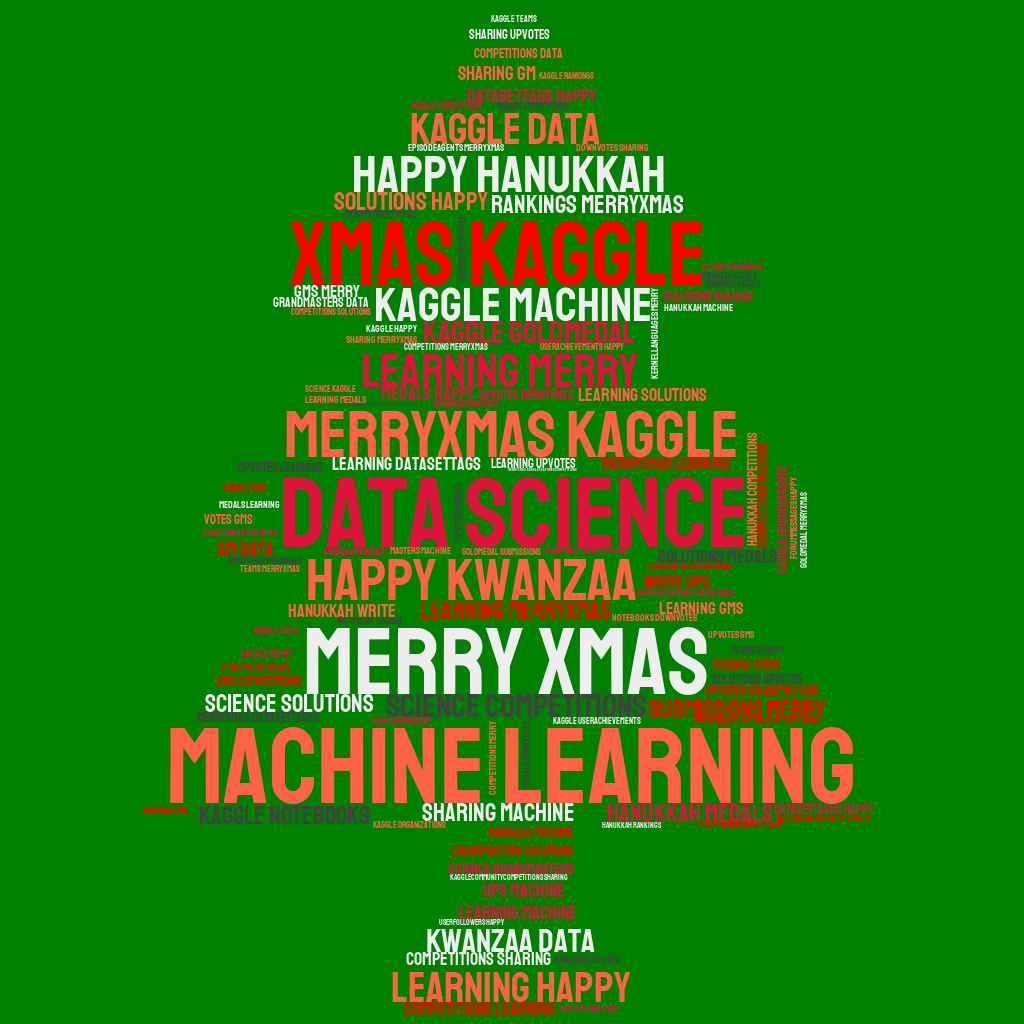

In [16]:
Image(filename="./stylecloud.png", width=1024, height=1024)

#It was suppose to be a Xmas Tree. A Happy Kwanzaa, Hanukkah, Merry Xmas Tree.

#Predict that a Cat isn't a Xmas Tree and Get a medal. Oh, No! Just Kudos.

![](https://i.kym-cdn.com/photos/images/facebook/002/285/296/93d.jpg)https://knowyourmeme.com/photos/2285296-cats

#Acknowledgements:

Kapa Kudaibergenov https://www.kaggle.com/kapakudaibergenov/stylecloud/notebook